In [148]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [149]:
df = pd.read_csv('./datasets/TSLA.csv')
close_prices = df['Close'].values.reshape(-1, 1)
close_prices

array([[   4.778   ],
       [   4.766   ],
       [   4.392   ],
       ...,
       [ 993.97998 ],
       [ 999.109985],
       [1013.919983]], shape=(2956, 1))

In [150]:
# MinMaxScaler: 값을 [0, 1] 범위로 정규화
# RNN/LSTM은 입력 스케일에 민감하므로 정규화 필수
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_prices)

# 시계열 데이터는 시간 순서를 유지해야 하므로 shuffle 없이 앞에서 자름
split     = int(len(scaled) * 0.8)
train_raw = scaled[:split]
test_raw  = scaled[split:]

# 슬라이딩 윈도우로 (X, y) 시퀀스 생성
# X[i]: scaled[i : i+60]  shape: (60, 1) — 과거 60일 종가
# y[i]: scaled[i+60]      shape: (1,)    — 다음 날 종가
# many-to-one: 60개 time step 입력 → 다음 1개 값 예측
seq_len = 60

def make_sequences(data):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train_raw)
X_test,  y_test  = make_sequences(test_raw)

In [151]:
class CustomDataset(Dataset):

    # LSTM input은 (batch, sequence_len, input_size) -> channel 필요 X
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)  # shape: (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

train_dataset = CustomDataset(X_train, y_train)
test_dataset  = CustomDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(len(train_dataset))
print(len(test_dataset))

2304
532


In [152]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=128,        # acc가 낮다면 x2, overfitting이거나 학습이 느리면 /2
            num_layers=2,
            batch_first=True,      # 입력 shape: (batch, seq, feature) 순서
            dropout=0.1            # num_layers > 1일 때 레이어 사이에 dropout 적용
        )

        self.fc = nn.Sequential(

            # in: hidden_size로 시작
            # out: in / 2 로 시작
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            # in: 이전 layer의 out
            # out: 회귀(regression)이므로 1
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # out : (batch, sequence_len, hidden_size) — 모든 time step hidden state
        # h_n : (num_layers, batch, hidden_size)   — 마지막 time step의 단기 hidden state
        # c_n : (num_layers, batch, hidden_size)   — 마지막 time step의 장기 cell state
        # RNN과 달리 LSTM은 c_n(cell state)을 추가로 반환 → 장기 의존성 문제 해결

        # many-to-one: 마지막 time step의 출력만 예측에 사용
        out = self.fc(out[:, -1, :])  # (batch, hidden_size) → (batch, 1)
        return out

model = LSTM()


In [153]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [154]:
train_losses, test_losses = [], []

In [155]:
epochs = 30

for epoch in range(epochs):

    # ── Train ──
    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # BPTT: 시간 펼침 역전파
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ── Test ──
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs   = model(X_batch)
            loss      = criterion(outputs, y_batch)
            test_loss += loss.item()

    test_loss = test_loss / len(test_loader)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.6f} | "
          f"Test Loss: {test_loss:.6f}")


Epoch [1/30] Train Loss: 0.000384 | Test Loss: 0.245292
Epoch [2/30] Train Loss: 0.000168 | Test Loss: 0.274114
Epoch [3/30] Train Loss: 0.000018 | Test Loss: 0.267385
Epoch [4/30] Train Loss: 0.000019 | Test Loss: 0.264114
Epoch [5/30] Train Loss: 0.000016 | Test Loss: 0.259767
Epoch [6/30] Train Loss: 0.000016 | Test Loss: 0.256455
Epoch [7/30] Train Loss: 0.000016 | Test Loss: 0.249737
Epoch [8/30] Train Loss: 0.000023 | Test Loss: 0.247677
Epoch [9/30] Train Loss: 0.000017 | Test Loss: 0.240352
Epoch [10/30] Train Loss: 0.000016 | Test Loss: 0.236468
Epoch [11/30] Train Loss: 0.000015 | Test Loss: 0.228808
Epoch [12/30] Train Loss: 0.000014 | Test Loss: 0.225935
Epoch [13/30] Train Loss: 0.000012 | Test Loss: 0.217352
Epoch [14/30] Train Loss: 0.000012 | Test Loss: 0.206201
Epoch [15/30] Train Loss: 0.000015 | Test Loss: 0.200215
Epoch [16/30] Train Loss: 0.000012 | Test Loss: 0.179039
Epoch [17/30] Train Loss: 0.000011 | Test Loss: 0.173138
Epoch [18/30] Train Loss: 0.000011 | Tes

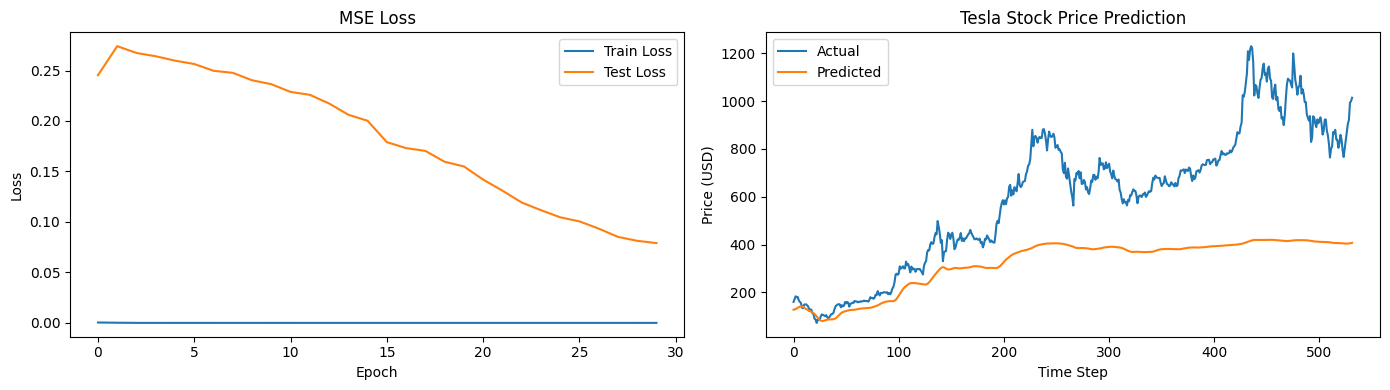

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Loss graph ──
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses,  label='Test Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ── pred vs true ──
model.eval()
predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        predictions.append(model(X_batch).numpy())

predictions = np.concatenate(predictions, axis=0)

# inverse_transform: 정규화된 예측값을 원래 주가 스케일로 복원
pred_prices   = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test)

axes[1].plot(actual_prices, label='Actual')
axes[1].plot(pred_prices,   label='Predicted')
axes[1].set_title('Tesla Stock Price Prediction')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()